# De-noising diffusion experiments

In [1]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Compose


from torch.utils.data import DataLoader


data_set = MNIST(
    root=".", download=True, transform=Compose([ToTensor(), lambda x: 2.0 * x - 1.0])
)

loader = DataLoader(dataset=data_set, batch_size=4)

test_batch = next(iter(loader))[0]

In [2]:
from torch import Tensor, tensor, log, exp, arange, cat
from torch.nn import Module, Sequential


class SinPosEmbedding(Module):
    """Sinusoidal position embedding block.

    Parameters
    ----------
    time_embedding_size : int
        The size of the time embedding.
    theta : int
        The number of timesteps (I think).

    """

    def __init__(self, time_embedding_size: int, theta: int = 10**4):
        """Build ``SinPosEmbedding``."""
        super().__init__()
        self._dim = time_embedding_size
        self._theta = tensor(theta)

    def forward(self, time: Tensor) -> Tensor:
        """Sinusoidally embed ``batch``.

        Parameters
        ----------
        time : Tensor
            The diffusion timestep.

        Returns
        -------
        Tensor
            A representation of time.

        """
        half_dim = self._dim // 2
        embeddings = log(self._theta) / (half_dim - 1)
        embeddings = exp(arange(half_dim, device=time.device) * -embeddings)

        embeddings = time[:, None] * embeddings[None, :]

        return cat((embeddings.sin(), embeddings.cos()), dim=-1)

In [3]:
from torch.nn import Sequential, Linear, ReLU


class TimeMLP(Sequential):
    """Time-embedding multi-layer perceptron.

    Parameters
    ----------
    embedding_size : int
        Size of the time embedding vector.
    theta : int
        The number of timesteps in the diffusion process.

    """

    def __init__(self, embedding_size: int, theta: int):
        """Build ``TimeMLP``."""
        super().__init__(
            SinPosEmbedding(embedding_size, theta=theta),
            Linear(embedding_size, embedding_size),
            ReLU(),
        )

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1987237].


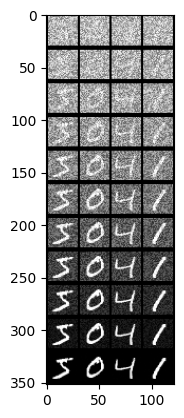

In [4]:
from torch import linspace, cumprod, Tensor, rand_like, rand, tensor
from torch.nn.functional import pad

from torchvision.utils import make_grid

import matplotlib.pyplot as plt


class DiffusionModel(Module):
    """Wrapper class for the diffusion model.

    Parameters
    ----------
    time_steps : int, optional
        Number of time steps in the process.


    """

    def __init__(self, time_steps: int = 1000):
        """Build ``DiffusionModel``."""
        super().__init__()

        self.register_buffer("betas", linspace(1e-4, 1e-2, time_steps))
        self.register_buffer("alphas", 1.0 - self.betas)
        self.register_buffer("alphas_cp", cumprod(self.alphas, dim=0))
        self.register_buffer(
            "alphas_cp_prev",
            pad(self.alphas_cp[:-1], (1, 0), value=1.0),
        )
        self.register_buffer("sqrt_recip_alphas", (1 / self.alphas).sqrt())
        self.register_buffer("sqrt_alpha_cp", self.alphas_cp.sqrt())
        self.register_buffer(
            "sqrt_one_minus_sqrt_alphs_cp", (1 - self.alphas_cp).sqrt()
        )
        self.register_buffer(
            "posterior_var",
            self.betas * (1.0 - self.alphas_cp_prev) / (1.0 - self.alphas_cp),
        )

    def generate_sample(self, batch: Tensor, time: Tensor) -> Tensor:
        """Generate a noisy sample."""
        batch_size = batch.shape[0]

        noise = rand_like(batch)

        sqrt_alpha_cp_t = self.sqrt_alpha_cp[time]
        sqrt_one_minus_sqrt_alphs_cp_t = self.sqrt_one_minus_sqrt_alphs_cp[time]

        return sqrt_alpha_cp_t * batch + sqrt_one_minus_sqrt_alphs_cp_t * noise


model = DiffusionModel()


imgs = []

for time in [999, 900, 800, 700, 600, 500, 400, 300, 200, 100, 0]:

    noisy = model.generate_sample(test_batch, tensor(time).long())
    noisy = 0.5 * noisy + 0.5

    imgs.append(make_grid(noisy, nrow=4).permute(1, 2, 0))

from torch import concat

imgs = concat(imgs, dim=0)

plt.imshow(imgs)
plt.show()

In [5]:
from torch_tools.models._blocks_2d import ConvBlock, ResidualBlock


from torch.nn import Linear, ConvTranspose2d, MaxPool2d


class Block(Module):
    """Single UNet block.

    Parameters
    ----------
    in_chans : int
        The number of input channels.
    time_embed_dim : int
        Size of the time embedding dimension.

    Notes
    -----
    The application of the up- or down-sampling here happen in slighly
    different places from the original UNet paper.

    """

    def __init__(self, in_chans: int, time_embed_dim: int, up=False):
        """Build single UNet ``Block``."""
        super().__init__()
        self.out_chans = 2 * in_chans if up is False else in_chans // 2

        self.time_mlp = Linear(time_embed_dim, self.out_chans)

        self.conv1 = ConvBlock(in_chans=in_chans, out_chans=self.out_chans)

        self.residual = ResidualBlock(in_chans=self.out_chans)

        if up is False:
            self.tfm = MaxPool2d(kernel_size=2, stride=2)
        else:
            self.tfm = ConvTranspose2d(
                in_channels=self.out_chans,
                out_channels=self.out_chans,
                kernel_size=2,
                stride=2,
            )

    def forward(self, mini_batch: Tensor, time_emb: Tensor) -> Tensor:
        """Pass ``mini_batch`` through the model.

        Paraneters
        ----------
        mini_batch : Tensor
            A mini-batch of inputs to down- or up-sample.
        time_emb : Tensor
            Time embedding.

        Returns
        -------
        Tensor
            Up-sampled ``mini_batch``.

        """
        representation = self.conv1(mini_batch)

        time_emb = self.time_mlp(time_emb).relu()[:, :, None, None]

        representation += time_emb

        representation = self.residual(representation)

        return self.tfm(representation)

In [7]:
from torch_tools.models._blocks_2d import ConvResBlock

from torch.nn import ModuleList, Conv2d


class DiffusionUNet(Module):
    """Diffusion UNet model."""

    def __init__(
        self,
        in_chans: int,
        out_chans: int,
        depth: int = 4,
        start_feats: int = 64,
        time_dim: int = 64,
    ):
        """Build ``DiffusionUNet``."""
        super().__init__()
        self.in_chans = in_chans
        self.out_chans = out_chans

        self.in_conv = ConvResBlock(
            in_chans=self.in_chans,
            out_chans=self.out_chans,
            lr_slope=0.1,
        )

        self.out_conv = Conv2d(
            in_channels=start_feats,
            out_channels=out_chans,
            kernel_size=1,
            stride=1,
        )

        self.downs = ModuleList()
        self.ups = ModuleList()

        for idx in range(depth - 1):

            self.downs.append(
                Block(
                    in_chans=start_feats * (2**idx),
                    time_embed_dim=time_dim,
                    up=False,
                )
            )

            self.ups.append(
                Block(
                    in_chans=start_feats * (2 ** (depth - 1)) // (2**idx),
                    time_embed_dim=time_dim,
                    up=True,
                )
            )

    def forward(self, batch : Tensor, time_step : int) -> Tensor:
        """Pass ``batch`` through the model.

        Parameters
        ----------
        batch : Tensor
            A mini-batch of inputs.
        time_step : int
            The time step we are at.

        Returns
        -------
        Tensor
            The result of passing ``batch`` through the model.

        """



model = DiffusionUNet(3, 3)
print(model)

DiffusionUNet(
  (in_conv): ConvResBlock(
    (0): ConvBlock(
      (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1)
    )
    (1): ResidualBlock(
      (first_conv): ConvBlock(
        (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.0)
      )
      (second_conv): ConvBlock(
        (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
  )
  (out_conv): Conv2d(64, 3, kernel_size=(1, 1), stride=(1, 1))
  (downs): ModuleList(
    (0): Block(
      (time_mlp): Linear(in_features=64, out_features=128, bias=True)
      (conv1): 